In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('/content/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [9]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df['age'] = df['age'].fillna(df['age'].median())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['charges'] >= lower) &
    (df['charges'] <= upper)
]


In [14]:
df.shape

(1199, 7)

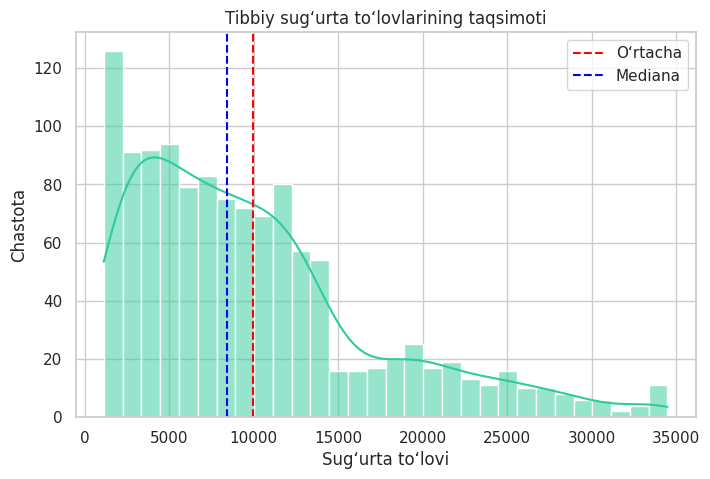

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['charges'],
    kde=True,
    bins=30,
    color='#2ECB9B'
)

plt.axvline(
    df['charges'].mean(),
    color='red',
    ls='--',
    label="O‘rtacha"
)

plt.axvline(
    df['charges'].median(),
    color='blue',
    ls='--',
    label='Mediana'
)

plt.legend()
plt.title('Tibbiy sug‘urta to‘lovlarining taqsimoti')
plt.xlabel('Sug‘urta to‘lovi')
plt.ylabel('Chastota')
plt.show()


/tmp/ipykernel_1436/759920750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


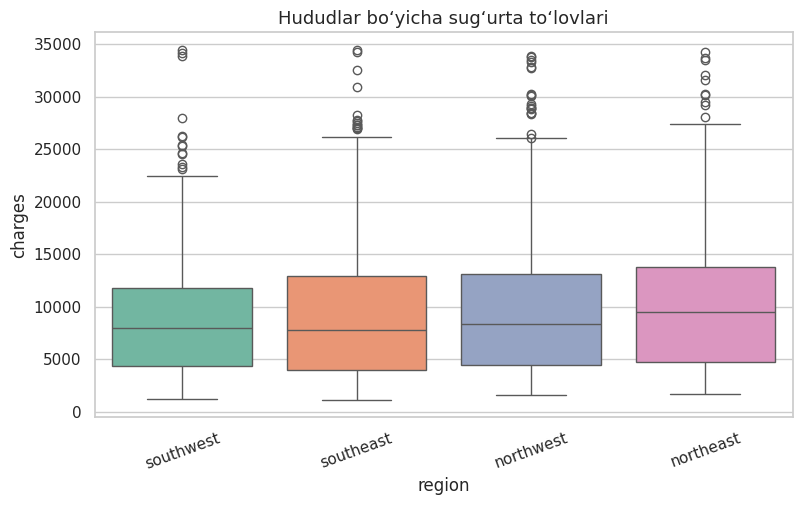

In [19]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='region',
    y='charges',
    palette='Set2'
)

plt.title('Hududlar bo‘yicha sug‘urta to‘lovlari', fontsize=13)
plt.xticks(rotation=20)

plt.show()


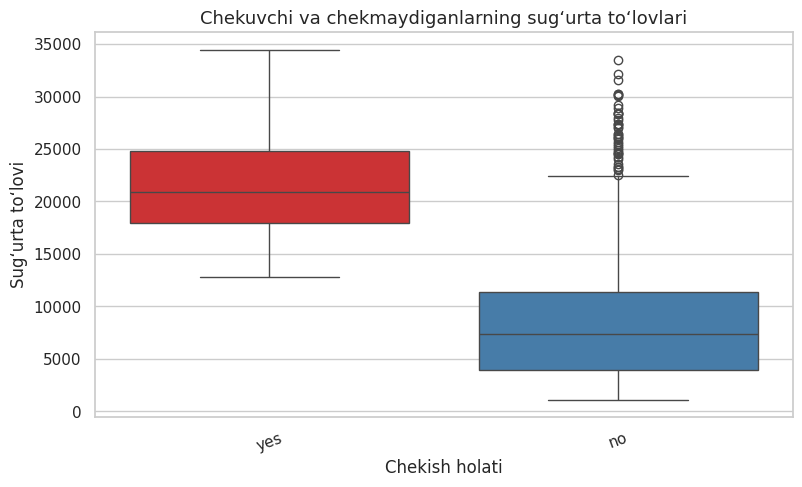

In [18]:
smoker_to_compare = ['yes', 'no']
df_filtered = df[df['smoker'].isin(smoker_to_compare)]

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_filtered,
    x='smoker',
    y='charges',
    palette='Set1',
    hue='smoker',
    legend=False
)

plt.title(
    'Chekuvchi va chekmaydiganlarning sug‘urta to‘lovlari',
    fontsize=13
)

plt.xlabel('Chekish holati')
plt.ylabel('Sug‘urta to‘lovi')

plt.xticks(rotation=20)
plt.show()


r = 0.44


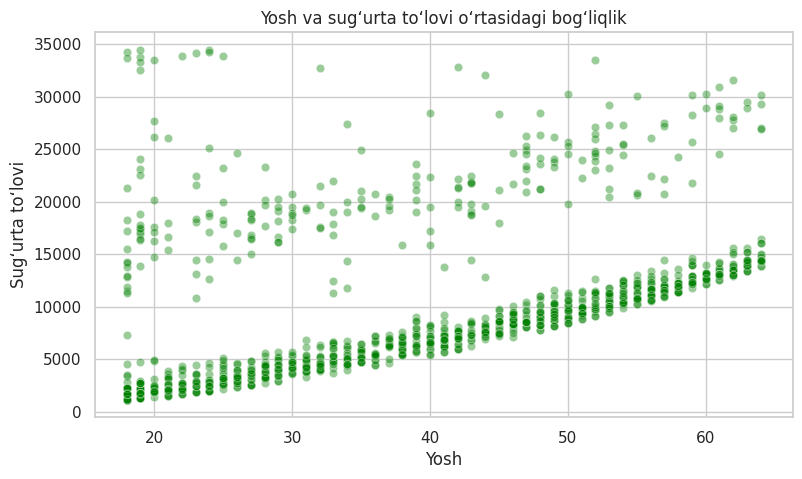

In [20]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    alpha=0.4,
    color='green'
)

r = df['age'].corr(df['charges'])

print(f'r = {r:.2f}')

plt.title('Yosh va sug‘urta to‘lovi o‘rtasidagi bog‘liqlik')
plt.xlabel('Yosh')
plt.ylabel('Sug‘urta to‘lovi')

plt.show()


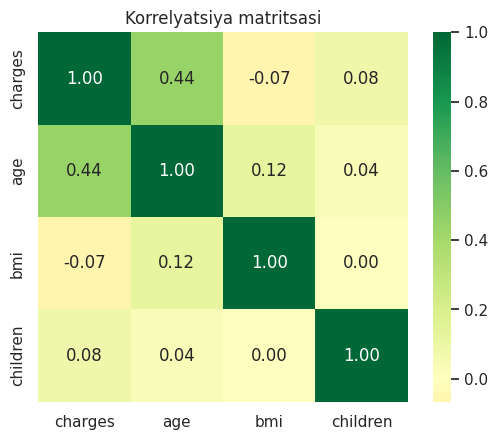

In [21]:
sonli = df[['charges', 'age', 'bmi', 'children']]

corr = sonli.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    fmt='.2f',
    square=True
)

plt.title('Korrelyatsiya matritsasi')
plt.show()


In [22]:
from scipy import stats

# Shapiro-Wilk normallik testi
sample = df['charges'].dropna().sample(
    min(500, df['charges'].dropna().shape[0]),
    random_state=1
)

stat, p = stats.shapiro(sample)

print(f'p-value = {p:.4f}')

if p < 0.05:
    print("Normal taqsimot emas!")
else:
    print("Normal taqsimotga yaqin!")


p-value = 0.0000
Normal taqsimot emas!


In [23]:
import numpy as np
from scipy import stats

charges = df['charges'].dropna()

n = len(charges)
mean = charges.mean()
se = stats.sem(charges)

# 95% ishonch oralig‘i
ci = stats.t.interval(
    0.95,
    n - 1,
    loc=mean,
    scale=se
)

print(f'O‘rtacha = {mean:.1f}')
print(f'95% CI = ({ci[0]:.1f}, {ci[1]:.1f})')


O‘rtacha = 9927.8
95% CI = (9517.5, 10338.0)


In [24]:
from scipy import stats

smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

t_stat, p = stats.ttest_ind(
    smokers,
    non_smokers,
    equal_var=False
)

print(f't = {t_stat:.2f}, p = {p:.4f}')


t = 27.18, p = 0.0000
